# Feature Representation Variations

This notebook investigates **Step 3: Feature Representation Variations** for empathy classification.

At this stage, we **fix the best model and the best preprocessing pipeline** found in the previous sections, and vary only the **feature representation**. This keeps the experiment controlled and lets us measure the effect of the representation itself.

## 1. Research question and hypothesis

### Research question
How does the choice of feature representation affect empathy classification performance when the **model** and **preprocessing** are fixed?

### Hypothesis
Different feature representations capture different types of signal:

- **TF-IDF unigram** is the reference representation.
- **TF-IDF unigram + bigram** may improve performance by capturing short empathetic phrases such as *"feel for"*, *"so sorry"*, or *"you are"*.
- **TF-IDF unigram + bigram + trigram** may capture more context, but may also become sparse and noisy.
- **Bag-of-Words** provides a simpler count-based baseline to compare against TF-IDF weighting.
- **Character n-grams** may help with informal writing, spelling variation, elongated words, and internet-style language.

### Experimental principle
Only the **feature representation** changes.  
Everything else stays fixed:
- **Model**: Logistic Regression
- **Preprocessing**: best preprocessing from Step 3 = **keep stopwords**
- **Train/test split**: same random seed and same test size for fair comparison

## 2. Experimental plan

We will run five experiments:

- **F1** — Best preprocessing + TF-IDF unigram  
- **F2** — Best preprocessing + TF-IDF unigram + bigram  
- **F3** — Best preprocessing + TF-IDF unigram + bigram + trigram  
- **F4** — Best preprocessing + Bag-of-Words  
- **F5** — Best preprocessing + Character n-grams  

### What we want to learn
This section answers a focused question:

> After choosing the best classical model and best preprocessing, what text representation gives the strongest signal for empathy detection?

We will compare the feature sets using:
- Accuracy
- Macro-F1
- Precision / Recall / F1 for the empathy class
- Precision / Recall / F1 for the no-empathy class
- Confusion matrices

In [1]:

import re
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    confusion_matrix
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 3. Download and load resources

We use NLTK resources for token normalization and stopword handling.  
Even though the selected preprocessing keeps stopwords, we keep the setup complete and reproducible.

In [2]:

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /Users/gjoli/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/gjoli/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/gjoli/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## 4. Load the dataset

This step loads the same dataset used in the previous notebooks.  
We keep the path logic flexible so the notebook works whether the dataset is in the current folder or in a common project location.

In [4]:
df = pd.read_csv("AcnEmpathize_dataset.csv")
df = df[['text', 'combined_empathy']].copy()
df = df.rename(columns={'combined_empathy': 'label'})
df.head()

,text,label
0,"Hello! I've been having a hard time, lingeri...",0
1,"Hey man the pictures are not present, can you ...",0
2,There are many many many many many many many d...,0
3,Maybe in some African tribe my face scars woul...,0
4,None of those opinions consider acne to be bea...,0


## 5. Basic cleaning of missing values and labels

Before applying preprocessing, we  make sure labels are numeric and binary.

This step is not one of the experimental variations.  
It is a **basic preparation step** required so that all experiments use valid input data.

In [ ]:
df = df[["text", "label"]].copy()
df = df.dropna(subset=["text", "label"])

# normalize labels
label_map = {
    "no_empathy": 0,
    "empathy": 1,
    
}
df["label"] = df["label"].map(lambda x: label_map.get(x, x))

# keep only binary labels
df = df[df["label"].isin([0, 1])].copy()
df["text"] = df["text"].astype(str)

print("Shape after filtering:", df.shape)
print(df["label"].value_counts(dropna=False))


Shape after filtering: (12212, 2)
label
0    9236
1    2976
Name: count, dtype: int64


## 6. Define the selected preprocessing pipeline

From Step 2, the best preprocessing was **keep stopwords**.  
So here we implement exactly that preprocessing and keep it fixed for all feature experiments.

### What this preprocessing does
- lowercase
- remove punctuation
- lemmatize
- **keep stopwords**

This design keeps relational words such as *you*, *I*, and *we*, which may be useful for empathy detection.

In [10]:

lemmatizer = WordNetLemmatizer()

def normalize_text_keep_stopwords(text: str) -> str:
    text = text.replace("\n", " ").replace("\r", " ").strip().lower()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    if not any(re.search(r"[a-z]", tok) for tok in tokens):
        return ""

    lemmas = [lemmatizer.lemmatize(tok) for tok in tokens]
    return " ".join(lemmas)

df["text_preprocessed"] = df["text"].apply(normalize_text_keep_stopwords)
df = df[df["text_preprocessed"].str.strip() != ""].copy()

df[["text_preprocessed", "label"]].head()

,text_preprocessed,label
0,hello i ve been having a hard time lingering a...,0
1,hey man the picture are not present can you po...,0
2,there are many many many many many many many d...,0
3,maybe in some african tribe my face scar would...,0
4,none of those opinion consider acne to be beau...,0


## 7. Train/test split

We create one fixed split and reuse it for all experiments.  
This is important for fairness: every feature representation is evaluated on the **same train and test instances**.

In [11]:

X = df["text_preprocessed"]
y = df["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest label distribution:")
print(y_test.value_counts(normalize=True))

Train size: 9769
Test size : 2443

Train label distribution:
label
0    0.75627
1    0.24373
Name: proportion, dtype: float64

Test label distribution:
label
0    0.756447
1    0.243553
Name: proportion, dtype: float64


## 8. Define the feature representation experiments

Now we define the five feature representations to compare.

### Why these settings?
- **F1** is the reference representation.
- **F2** tests whether short phrases help.
- **F3** tests whether more context helps or hurts.
- **F4** checks whether raw counts are enough.
- **F5** checks whether subword patterns help with informal language.

In [12]:

feature_configs = {
    "F1_tfidf_unigram": TfidfVectorizer(
        ngram_range=(1, 1),
        max_features=5000
    ),
    "F2_tfidf_unigram_bigram": TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=5000
    ),
    "F3_tfidf_unigram_bigram_trigram": TfidfVectorizer(
        ngram_range=(1, 3),
        max_features=5000
    ),
    "F4_bag_of_words": CountVectorizer(
        ngram_range=(1, 1),
        max_features=5000
    ),
    "F5_character_ngrams": TfidfVectorizer(
        analyzer="char_wb",
        ngram_range=(3, 5),
        max_features=5000
    ),
}

## 9. Define the fixed model

We keep the best model from the baseline section: **Logistic Regression**.

The goal here is not to tune the model again.  
The goal is to isolate the effect of the **feature representation**.

In [ ]:

def build_model():
    return LogisticRegression(
        max_iter=1000,
        random_state=42
    )

## 10. Define the evaluation function

This helper function trains one experiment, predicts on the test set, and returns:

- the trained vectorizer
- the trained model
- predictions
- evaluation metrics

This keeps the notebook clean and makes the experiment loop easier to read.

In [14]:

def run_experiment(experiment_name, vectorizer, X_train, X_test, y_train, y_test):
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = build_model()
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=[1, 0], zero_division=0
    )
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    result = {
        "experiment": experiment_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "precision_empathy": precision[0],
        "recall_empathy": recall[0],
        "f1_empathy": f1[0],
        "precision_no_empathy": precision[1],
        "recall_no_empathy": recall[1],
        "f1_no_empathy": f1[1],
        "n_features_used": X_train_vec.shape[1],
    }

    return {
        "vectorizer": vectorizer,
        "model": model,
        "y_pred": y_pred,
        "metrics": result
    }

## 11. Run all feature representation experiments

This is the core experiment loop.

For each feature representation:
1. vectorize the preprocessed text
2. train Logistic Regression
3. evaluate on the same test split
4. store results for comparison

In [15]:

results = []
predictions = {}
trained_objects = {}

for exp_name, vectorizer in feature_configs.items():
    output = run_experiment(exp_name, vectorizer, X_train, X_test, y_train, y_test)
    results.append(output["metrics"])
    predictions[exp_name] = output["y_pred"]
    trained_objects[exp_name] = {
        "vectorizer": output["vectorizer"],
        "model": output["model"]
    }

results_df = pd.DataFrame(results).sort_values(
    by=["macro_f1", "f1_empathy", "accuracy"],
    ascending=False
).reset_index(drop=True)

results_df

,experiment,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,n_features_used
0,F3_tfidf_unigram_bigram_trigram,0.848138,0.754654,0.829412,0.473950,0.603209,0.851165,0.968615,0.906100,5000
1,F2_tfidf_unigram_bigram,0.846500,0.752815,0.819767,0.473950,0.600639,0.850881,0.966450,0.904991,5000
2,F1_tfidf_unigram,0.835448,0.737773,0.770308,0.462185,0.577731,0.846596,0.955628,0.897814,5000
3,F4_bag_of_words,0.810070,0.734558,0.620183,0.568067,0.592982,0.864594,0.887987,0.876135,5000
4,F5_character_ngrams,0.831355,0.732102,0.753463,0.457143,0.569038,0.844861,0.951840,0.895165,5000


## 12. Highlight the best result

Macro-F1 is the main comparison metric here because the dataset is imbalanced.  
Accuracy alone would over-reward predictions of the majority class.

In [17]:

results_df.style.background_gradient(
    subset=["macro_f1", "recall_empathy", "f1_empathy"],
    cmap="Blues"
)

,experiment,accuracy,macro_f1,precision_empathy,recall_empathy,f1_empathy,precision_no_empathy,recall_no_empathy,f1_no_empathy,n_features_used
0,F3_tfidf_unigram_bigram_trigram,0.848138,0.754654,0.829412,0.473950,0.603209,0.851165,0.968615,0.906100,5000
1,F2_tfidf_unigram_bigram,0.846500,0.752815,0.819767,0.473950,0.600639,0.850881,0.966450,0.904991,5000
2,F1_tfidf_unigram,0.835448,0.737773,0.770308,0.462185,0.577731,0.846596,0.955628,0.897814,5000
3,F4_bag_of_words,0.810070,0.734558,0.620183,0.568067,0.592982,0.864594,0.887987,0.876135,5000
4,F5_character_ngrams,0.831355,0.732102,0.753463,0.457143,0.569038,0.844861,0.951840,0.895165,5000


## 13. Visual comparison of the main metrics

This plot makes it easier to compare the representations side by side, especially for:
- Macro-F1
- Empathy precision
- Empathy recall
- Empathy F1

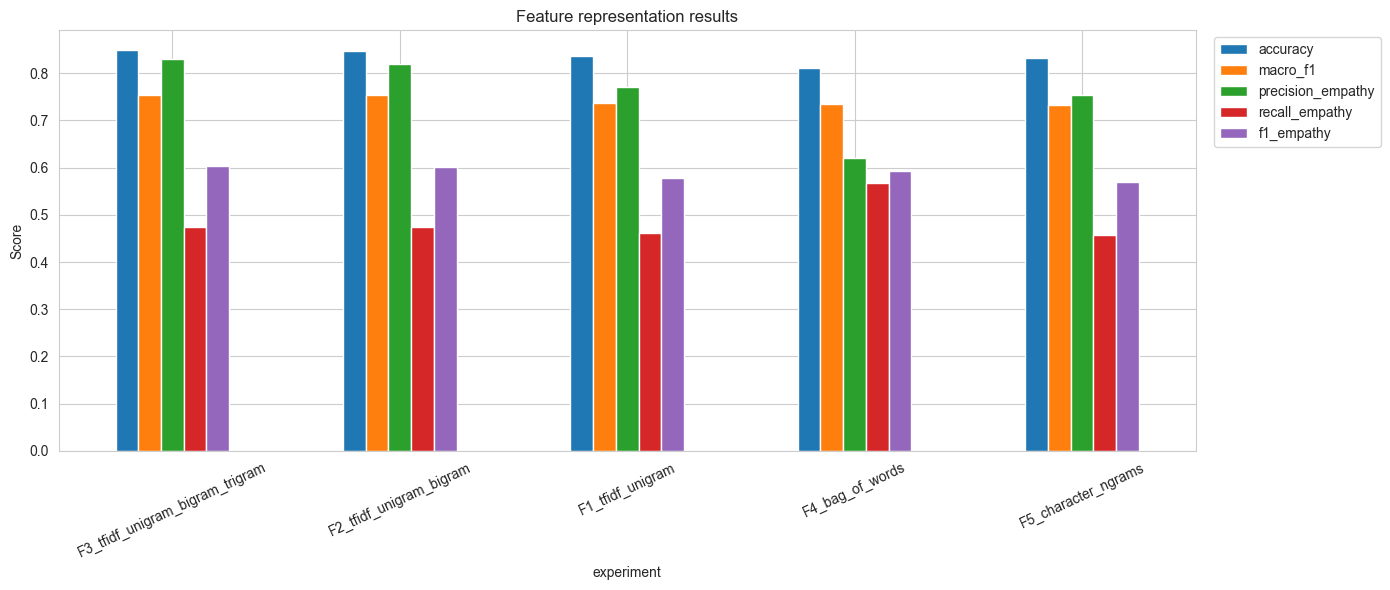

In [18]:

plot_df = results_df.copy()

metrics_to_plot = [
    "accuracy",
    "macro_f1",
    "precision_empathy",
    "recall_empathy",
    "f1_empathy"
]

ax = plot_df.set_index("experiment")[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 6),
    rot=25
)
ax.set_title("Feature representation results")
ax.set_ylabel("Score")
ax.set_xlabel("experiment")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

## 14. Confusion matrices

Confusion matrices help us inspect the error profile of each representation:
- How many empathy posts are correctly found?
- How many are missed?
- Is the model biased toward predicting no-empathy?

We plot them side by side for direct comparison.

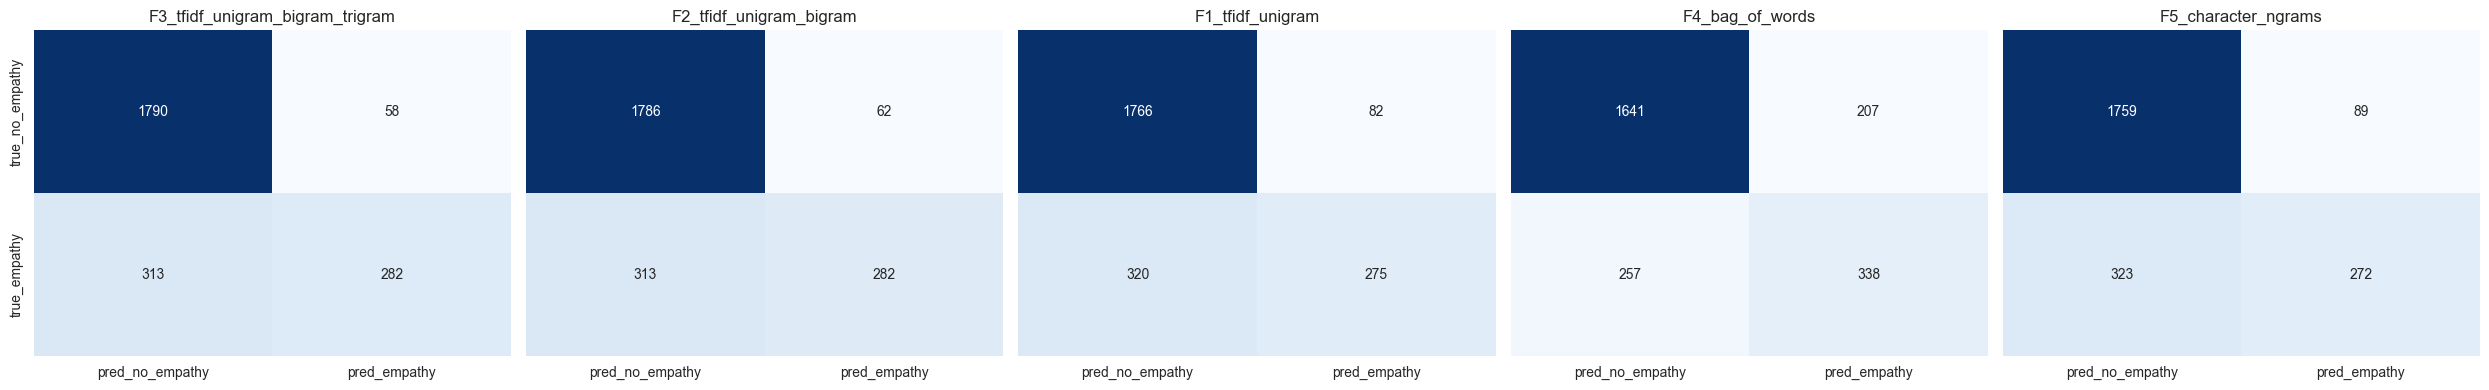

In [19]:

n_models = len(predictions)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), sharey=True)

if n_models == 1:
    axes = [axes]

ordered_experiments = results_df["experiment"].tolist()

for ax, exp_name in zip(axes, ordered_experiments):
    y_pred = predictions[exp_name]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["pred_no_empathy", "pred_empathy"],
        yticklabels=["true_no_empathy", "true_empathy"]
    )
    ax.set_title(exp_name)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

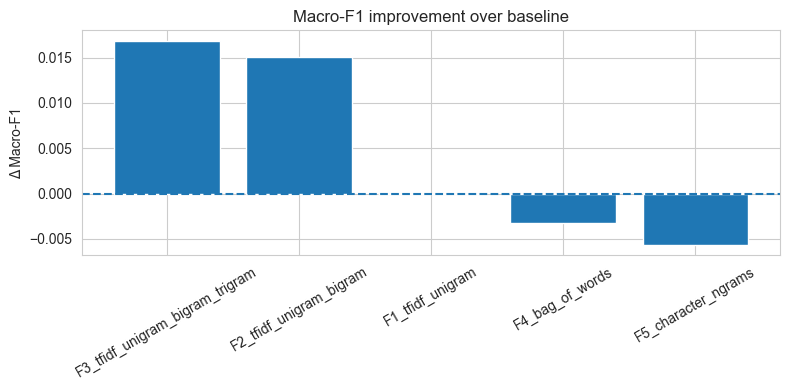

In [22]:
plt.figure(figsize=(8, 4))

plt.bar(delta_df["experiment"], delta_df["macro_f1"])
plt.axhline(0, linestyle="--")
plt.title("Macro-F1 improvement over baseline")
plt.ylabel("Δ Macro-F1")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Conclusions

Feature representation has a clear impact, especially on empathy detection.

- Best overall: F3 (TF-IDF unigram + bigram + trigram)
    - Highest accuracy (~0.85), Macro-F1 (~0.75), and empathy F1 (~0.60)
    - Best balance between precision and recall
        → Adding higher-order n-grams helps capture context and phrasing

- F2 (unigram + bigram) is very close to F3
    → Most of the gain comes from bigrams, trigrams add small improvement
- F1 (unigram) performs worse
    → Single words miss important contextual signals (e.g., “I understand”)
- F4 (Bag-of-Words):
    - Much higher empathy recall (~0.57)
    - But lower precision and overall performance
    → Over-predicts empathy (more false positives)

- F5 (character n-grams):
    - Slightly worse than TF-IDF n-grams
    → Helps with informal text, but less effective than word-level context

- **Key insight**
    - Empathy detection benefits from phrase-level information
    - Best trade-off: TF-IDF with n-grams (especially bigrams)